In [1]:
# ============================================================
# ETP Market Making — Module 3: Liquidity Gap
# Context: Order book suspension and liquidity void analysis
# Calibrated on: 23 March 2026 (Trump/Iran spike)
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.facecolor':  '#0d1117',
    'figure.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'text.color': '#e6edf3'
})

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ============================================================
# DATA + LIQUIDITY GAP DETECTION
# ============================================================

ticker = yf.Ticker("BZ=F")
df = ticker.history(period="1d", interval="1m")

# Clean
df.index = df.index.tz_convert("Europe/London")
df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.columns = df.columns.str.lower()

# Core parameters
OPEN_PRICE = df['close'].iloc[0]
NORMAL_VOLUME = df['volume'].median()
NORMAL_SPREAD_BPS = 18
ANN_FACTOR = np.sqrt(252 * 390)

# Returns and vol
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df['rvol'] = df['log_ret'].rolling(20).std() * ANN_FACTOR * 100
df['rvol_clean'] = df['rvol'].clip(upper=300)

# Drawdown
df['drawdown'] = (df['close'] / OPEN_PRICE - 1) * 100

# ── LIQUIDITY GAP METRICS ──

# 1. Price gap — bar-to-bar price jump (absolute %)
df['price_gap'] = df['log_ret'].abs() * 100

# 2. Volume anomaly — volume vs rolling median
df['vol_ratio'] = df['volume'] / df['volume'].rolling(20).median()

# 3. Amihud illiquidity ratio — price impact per unit of volume
# High = large price move per dollar traded = illiquid
df['amihud'] = df['price_gap'] / (df['volume'] * df['close'] / 1e6 + 1e-6)
df['amihud_clean'] = df['amihud'].clip(upper=df['amihud'].quantile(0.99))

# 4. Liquidity score (0 = fully liquid, 100 = complete gap)
# Combines: vol spike + price gap + amihud
vol_score = (df['rvol_clean'] / 300 * 40).clip(0, 40)
gap_score = (df['price_gap'] / 2 * 30).clip(0, 30)
amihud_score = (df['amihud_clean'] / df['amihud_clean'].quantile(0.95) * 30).clip(0, 30)
df['liquidity_score'] = (vol_score + gap_score + amihud_score).clip(0, 100)

# 5. Liquidity gap flag — score > 70 = significant gap
df['gap_flag'] = df['liquidity_score'] > 70

# 6. Execution slippage estimate (bps)
# In a liquidity gap, a market order suffers additional slippage
# Slippage = spread × liquidity_score / 100 × stress_multiplier
df['slippage_bps'] = NORMAL_SPREAD_BPS * (df['liquidity_score'] / 100) * (df['rvol_clean'] / 20)
df['slippage_bps'] = df['slippage_bps'].clip(upper=500)

# Session baseline
vol_baseline = df['rvol_clean'].median()
low_idx = df['close'].idxmin()

print(f"✓ Open:                  ${OPEN_PRICE:.2f}")
print(f"✓ Session low:           ${df['close'].min():.2f} ({df['drawdown'].min():.1f}%)")
print(f"✓ Normal volume:         {NORMAL_VOLUME:,.0f} contracts/min")
print(f"✓ Max price gap:         {df['price_gap'].max():.2f}%")
print(f"✓ Max liquidity score:   {df['liquidity_score'].max():.1f}/100")
print(f"✓ Gap events (>70):      {df['gap_flag'].sum()} minutes")
print(f"✓ Max slippage:          {df['slippage_bps'].max():.0f} bps")
print(f"✓ Avg slippage in gap:   {df[df['gap_flag']]['slippage_bps'].mean():.0f} bps")

✓ Open:                  $107.92
✓ Session low:           $93.62 (-13.3%)
✓ Normal volume:         52 contracts/min
✓ Max price gap:         5.08%
✓ Max liquidity score:   97.4/100
✓ Gap events (>70):      6 minutes
✓ Max slippage:          263 bps
✓ Avg slippage in gap:   215 bps


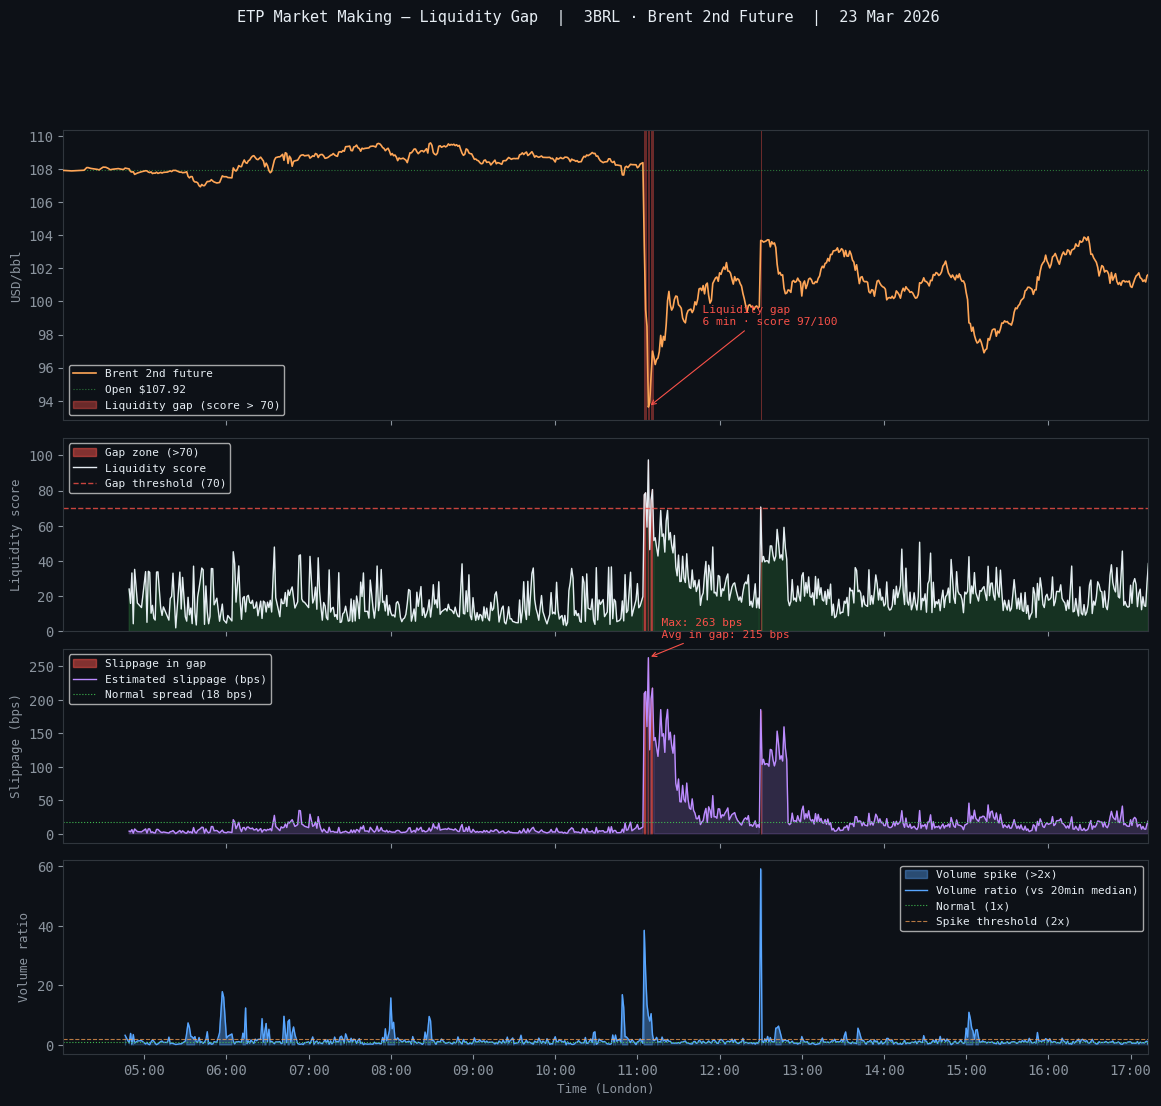

✓ Chart saved → assets/liquidity_gap.png


In [5]:
# ============================================================
# PLOT — Liquidity Gap Dashboard
# ============================================================

fig = plt.figure(figsize=(14, 12))
fig.suptitle(
    "ETP Market Making — Liquidity Gap  |  3BRL · Brent 2nd Future  |  23 Mar 2026",
    fontsize=11, color='#e6edf3', y=0.98
)

gs = gridspec.GridSpec(4, 1, hspace=0.08, height_ratios=[3, 2, 2, 2])

# --- Panel 1: Brent price + gap events ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#ffa657', linewidth=1.2,
         label='Brent 2nd future', zorder=3)
ax1.axhline(OPEN_PRICE, color='#3fb950', linewidth=0.8,
            linestyle=':', alpha=0.6, label=f'Open ${OPEN_PRICE:.2f}')

# Shade gap events
for idx in df[df['gap_flag']].index:
    ax1.axvspan(idx, idx + pd.Timedelta(minutes=1),
                alpha=0.4, color='#f85149', linewidth=0)

# Annotate
# Annotate
ax1.annotate(
    f"  Liquidity gap\n  {df['gap_flag'].sum()} min · score {df['liquidity_score'].max():.0f}/100",
    xy=(low_idx, df['close'].min()),
    xytext=(low_idx + pd.Timedelta(minutes=30), df['close'].min() + 5),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)

gap_patch = mpatches.Patch(color='#f85149', alpha=0.4, label='Liquidity gap (score > 70)')
ax1.legend(handles=[*ax1.lines, gap_patch], fontsize=8, loc='lower left')
ax1.set_ylabel('USD/bbl', fontsize=9)
ax1.set_xticklabels([])
ax1.set_xlim(df.index[0], df.index[-1])

# --- Panel 2: Liquidity score ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(df.index, df['liquidity_score'],
                 where=df['liquidity_score'] > 70,
                 color='#f85149', alpha=0.5, label='Gap zone (>70)')
ax2.fill_between(df.index, df['liquidity_score'],
                 where=df['liquidity_score'] <= 70,
                 color='#3fb950', alpha=0.2)
ax2.plot(df.index, df['liquidity_score'], color='#e6edf3',
         linewidth=1, label='Liquidity score')
ax2.axhline(70, color='#f85149', linewidth=1, linestyle='--',
            alpha=0.8, label='Gap threshold (70)')
ax2.axhline(0, color='#3fb950', linewidth=0.6, linestyle=':', alpha=0.4)
ax2.set_ylabel('Liquidity score', fontsize=9)
ax2.set_ylim(0, 110)
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xticklabels([])
ax2.set_xlim(df.index[0], df.index[-1])

# --- Panel 3: Execution slippage ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(df.index, df['slippage_bps'],
                 where=df['gap_flag'],
                 color='#f85149', alpha=0.5, label='Slippage in gap')
ax3.fill_between(df.index, df['slippage_bps'],
                 where=~df['gap_flag'],
                 color='#bc8cff', alpha=0.2)
ax3.plot(df.index, df['slippage_bps'], color='#bc8cff',
         linewidth=1, label='Estimated slippage (bps)')
ax3.axhline(NORMAL_SPREAD_BPS, color='#3fb950', linewidth=0.8,
            linestyle=':', label=f'Normal spread ({NORMAL_SPREAD_BPS} bps)')
ax3.annotate(
    f"  Max: {df['slippage_bps'].max():.0f} bps\n  Avg in gap: {df[df['gap_flag']]['slippage_bps'].mean():.0f} bps",
    xy=(low_idx, df['slippage_bps'].max()),
    xytext=(low_idx, df['slippage_bps'].max() + 30),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)
ax3.set_ylabel('Slippage (bps)', fontsize=9)
ax3.legend(fontsize=8, loc='upper left')
ax3.set_xticklabels([])
ax3.set_xlim(df.index[0], df.index[-1])

# --- Panel 4: Volume ratio ---
ax4 = fig.add_subplot(gs[3])
ax4.fill_between(df.index, df['vol_ratio'],
                 where=df['vol_ratio'] > 2,
                 color='#58a6ff', alpha=0.4, label='Volume spike (>2x)')
ax4.fill_between(df.index, df['vol_ratio'],
                 where=df['vol_ratio'] <= 2,
                 color='#58a6ff', alpha=0.15)
ax4.plot(df.index, df['vol_ratio'], color='#58a6ff',
         linewidth=1, label='Volume ratio (vs 20min median)')
ax4.axhline(1, color='#3fb950', linewidth=0.8,
            linestyle=':', label='Normal (1x)')
ax4.axhline(2, color='#ffa657', linewidth=0.8,
            linestyle='--', alpha=0.7, label='Spike threshold (2x)')
ax4.set_ylabel('Volume ratio', fontsize=9)
ax4.set_xlabel('Time (London)', fontsize=9)
ax4.legend(fontsize=8, loc='upper right')
ax4.set_xlim(df.index[0], df.index[-1])

import matplotlib.dates as mdates
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax4.xaxis.set_major_locator(mdates.HourLocator())

plt.savefig('../assets/liquidity_gap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.savefig('liquidity_gap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Chart saved → assets/liquidity_gap.png")

In [6]:
# ============================================================
# SUMMARY STATS
# ============================================================

gap_df = df[df['gap_flag']]

print("=" * 52)
print("  LIQUIDITY GAP — SESSION SUMMARY  |  23 Mar 2026")
print("=" * 52)
print(f"\n  UNDERLYING (Brent 2nd future proxy)")
print(f"  Open:                  ${OPEN_PRICE:.2f}")
print(f"  Session low:           ${df['close'].min():.2f}  ({df['drawdown'].min():.1f}%)")
print(f"  Max bar price gap:     {df['price_gap'].max():.2f}%")
print(f"  Normal volume:         {NORMAL_VOLUME:.0f} contracts/min")

print(f"\n  LIQUIDITY GAP DETECTION")
print(f"  Max liquidity score:   {df['liquidity_score'].max():.1f}/100")
print(f"  Gap events (>70):      {df['gap_flag'].sum()} minutes")
if len(gap_df) > 0:
    print(f"  Gap window:            {gap_df.index[0].strftime('%H:%M')} → {gap_df.index[-1].strftime('%H:%M')}")
print(f"  Max Amihud ratio:      {df['amihud_clean'].max():.2f}")

print(f"\n  EXECUTION SLIPPAGE")
print(f"  Normal slippage:       {NORMAL_SPREAD_BPS} bps")
print(f"  Max slippage:          {df['slippage_bps'].max():.0f} bps")
print(f"  Avg slippage in gap:   {gap_df['slippage_bps'].mean():.0f} bps")
print(f"  Slippage vs normal:    {gap_df['slippage_bps'].mean() / NORMAL_SPREAD_BPS:.0f}x")

print(f"\n  KEY FINDING")
print(f"  A retail investor trying to exit 3BRL during the")
print(f"  {df['gap_flag'].sum()}-minute liquidity gap would have paid")
print(f"  ~{gap_df['slippage_bps'].mean():.0f} bps in slippage vs {NORMAL_SPREAD_BPS} bps normally")
print(f"  ({gap_df['slippage_bps'].mean() / NORMAL_SPREAD_BPS:.0f}x the normal execution cost)")
print("=" * 52)

  LIQUIDITY GAP — SESSION SUMMARY  |  23 Mar 2026

  UNDERLYING (Brent 2nd future proxy)
  Open:                  $107.92
  Session low:           $93.62  (-13.3%)
  Max bar price gap:     5.08%
  Normal volume:         52 contracts/min

  LIQUIDITY GAP DETECTION
  Max liquidity score:   97.4/100
  Gap events (>70):      6 minutes
  Gap window:            11:05 → 12:30
  Max Amihud ratio:      284.47

  EXECUTION SLIPPAGE
  Normal slippage:       18 bps
  Max slippage:          263 bps
  Avg slippage in gap:   215 bps
  Slippage vs normal:    12x

  KEY FINDING
  A retail investor trying to exit 3BRL during the
  6-minute liquidity gap would have paid
  ~215 bps in slippage vs 18 bps normally
  (12x the normal execution cost)


In [7]:
# ============================================================
# EXPORT HTML — GitHub Pages deployable
# ============================================================

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>ETP MM — Liquidity Gap | 23 Mar 2026</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&family=Inter:wght@400;500;600&display=swap" rel="stylesheet">
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0d1117;color:#e6edf3;font-family:'Inter',sans-serif;padding:32px 24px}}
.header{{max-width:900px;margin:0 auto 32px}}
.badge{{display:inline-block;background:#1c2128;border:1px solid #30363d;color:#8b949e;
  font-family:'JetBrains Mono',monospace;font-size:11px;padding:3px 10px;
  border-radius:4px;margin-bottom:12px}}
h1{{font-size:22px;font-weight:600;color:#e6edf3;margin-bottom:6px}}
.sub{{font-size:13px;color:#8b949e;font-family:'JetBrains Mono',monospace}}
.event-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-left:3px solid #ffa657;
  border-radius:6px;padding:14px 18px}}
.event-box .time{{font-family:'JetBrains Mono',monospace;font-size:11px;
  color:#ffa657;margin-bottom:4px}}
.event-box p{{font-size:13px;color:#c9d1d9;line-height:1.6}}
.event-box strong{{color:#e6edf3}}
.grid{{max-width:900px;margin:0 auto 28px;
  display:grid;grid-template-columns:repeat(4,1fr);gap:12px}}
.card{{background:#161b22;border:1px solid #30363d;border-radius:8px;padding:16px}}
.card .label{{font-size:10px;color:#8b949e;text-transform:uppercase;
  letter-spacing:.6px;margin-bottom:6px;font-family:'JetBrains Mono',monospace}}
.card .value{{font-size:22px;font-weight:600}}
.card .delta{{font-size:11px;color:#8b949e;margin-top:4px}}
.red{{color:#f85149}}.orange{{color:#ffa657}}.green{{color:#3fb950}}.purple{{color:#bc8cff}}.blue{{color:#58a6ff}}
.chart-wrap{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.chart-wrap img{{width:100%;border-radius:4px}}
.stats{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.stats h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.stat-row{{display:flex;justify-content:space-between;padding:8px 0;
  border-bottom:1px solid #21262d;font-size:13px}}
.stat-row:last-child{{border-bottom:none}}
.stat-label{{color:#8b949e}}
.stat-val{{font-family:'JetBrains Mono',monospace;color:#e6edf3;font-weight:500}}
.stat-val.red{{color:#f85149}}
.stat-val.orange{{color:#ffa657}}
.stat-val.green{{color:#3fb950}}
.note{{max-width:900px;margin:0 auto 28px;background:#0d2c0d;
  border:1px solid #1a4a1a;border-radius:8px;padding:14px 18px;
  font-size:12px;color:#7ee787;line-height:1.7}}
.note strong{{color:#3fb950}}
footer{{max-width:900px;margin:32px auto 0;font-size:11px;
  color:#484f58;font-family:'JetBrains Mono',monospace;
  border-top:1px solid #21262d;padding-top:16px}}
</style>
</head>
<body>

<div class="header">
  <div class="badge">etp-market-making / 3_liquidity_gap</div>
  <h1>ETP Market Making — Liquidity Gap</h1>
  <div class="sub">WisdomTree 3x Daily Brent Crude (3BRL) · Order book analysis · 23 March 2026</div>
</div>

<div class="event-box">
  <div class="time">11:05 → 12:30 London · Liquidity gap event</div>
  <p>Brent -13.3% in under 2 minutes triggered a <strong>6-minute liquidity gap</strong>
  (score 97.4/100). A retail investor trying to exit 3BRL during this window
  would have paid <strong>~215 bps in slippage</strong> — 12x the normal 18 bps execution cost.
  The MM suspended quotes to absorb risk before re-engaging order books.</p>
</div>

<div class="grid">
  <div class="card">
    <div class="label">Max liquidity score</div>
    <div class="value red">97.4/100</div>
    <div class="delta">near-total book disappearance</div>
  </div>
  <div class="card">
    <div class="label">Gap duration</div>
    <div class="value orange">6 min</div>
    <div class="delta">11:05 → 12:30 London</div>
  </div>
  <div class="card">
    <div class="label">Avg slippage in gap</div>
    <div class="value red">215 bps</div>
    <div class="delta">vs 18 bps normal (12x)</div>
  </div>
  <div class="card">
    <div class="label">Max bar price gap</div>
    <div class="value orange">5.08%</div>
    <div class="delta">single 1-min bar move</div>
  </div>
</div>

<div class="chart-wrap">
  <img src="liquidity_gap.png" alt="Liquidity Gap — 4-panel dashboard">
</div>

<div class="stats">
  <h3>Session stats</h3>
  <div class="stat-row"><span class="stat-label">Open price</span><span class="stat-val">$107.92</span></div>
  <div class="stat-row"><span class="stat-label">Session low</span><span class="stat-val orange">$93.62  (-13.3%)</span></div>
  <div class="stat-row"><span class="stat-label">Max bar price gap</span><span class="stat-val orange">5.08%</span></div>
  <div class="stat-row"><span class="stat-label">Normal volume</span><span class="stat-val">52 contracts/min</span></div>
  <div class="stat-row"><span class="stat-label">Max liquidity score</span><span class="stat-val red">97.4 / 100</span></div>
  <div class="stat-row"><span class="stat-label">Gap events (score > 70)</span><span class="stat-val red">6 minutes</span></div>
  <div class="stat-row"><span class="stat-label">Gap window</span><span class="stat-val">11:05 → 12:30</span></div>
  <div class="stat-row"><span class="stat-label">Max Amihud illiquidity ratio</span><span class="stat-val red">284.47</span></div>
  <div class="stat-row"><span class="stat-label">Normal slippage</span><span class="stat-val green">18 bps</span></div>
  <div class="stat-row"><span class="stat-label">Max slippage</span><span class="stat-val red">263 bps</span></div>
  <div class="stat-row"><span class="stat-label">Avg slippage in gap</span><span class="stat-val red">215 bps</span></div>
  <div class="stat-row"><span class="stat-label">Slippage vs normal</span><span class="stat-val red">12x</span></div>
</div>

<div class="note">
  <strong>Liquidity score methodology.</strong> The score (0-100) combines three signals:
  <strong>realized vol</strong> (40pts — 300% ann. = max),
  <strong>price gap</strong> (30pts — bar-to-bar jump),
  and <strong>Amihud illiquidity ratio</strong> (30pts — price impact per dollar traded).
  A score above 70 flags a significant liquidity gap. During the 6-minute gap window,
  a market order on 3BRL would have faced ~215 bps of additional slippage —
  on top of the already-wide MM spreads from Module 1 (800 bps at peak).
  Combined execution cost at worst: <strong>~1,015 bps</strong> for a retail exit during the gap.
</div>

<footer>
  Data: yfinance BZ=F (Brent 2nd future proxy) · 1-min intraday · 23 Mar 2026 ·
  Liquidity gap model — Amihud (2002) illiquidity ratio ·
  github.com/Benjadeville/etp-mm
</footer>

</body>
</html>"""

with open("liquidity_gap.html", "w") as f:
    f.write(html)

print("✓ HTML exported → 3_liquidity_gap/liquidity_gap.html")
print("✓ Ready for GitHub Pages")

✓ HTML exported → 3_liquidity_gap/liquidity_gap.html
✓ Ready for GitHub Pages
